In [70]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt


In [71]:
# Geometría EF-Schwarzschild en Σ_t
def A_of_r(r, Rs):
    return 1.0 + Rs / r

def p_of_r(r, Rs):
    return r**2 / np.sqrt(A_of_r(r, Rs))   # p=r^2/sqrt(A)

def w_of_r(r, Rs):
    return r**2 * np.sqrt(A_of_r(r, Rs))   # w=r^2*sqrt(A)

def q_of_r(r, ell):
    return ell * (ell + 1.0) / (r**2)      # q=ell(ell+1)/r^2


In [72]:
def build_matrices_uniform(rmin, rmax, Nr, Rs, ell, kappa=None):
    r = np.linspace(rmin, rmax, Nr)
    dr = (rmax - rmin) / (Nr - 1)

    if kappa is None:
        # Robin "radiativa" típica: e'(rmax) + (ell+1)/rmax e(rmax)=0
        kappa = (ell + 1.0) / rmax

    p = p_of_r(r, Rs)
    w = w_of_r(r, Rs)
    q = q_of_r(r, ell)

    # p en caras (promedio armónico) para estabilidad
    p_face = 2.0 * p[:-1] * p[1:] / (p[:-1] + p[1:] + 1e-300)  # Nr-1
    coeff = p_face / dr                                         # Nr-1

    # K: rigidez para -d/dr(p du/dr)
    main = np.zeros(Nr)
    off  = np.zeros(Nr - 1)
    main[:-1] += coeff
    main[1:]  += coeff
    off[:]    -= coeff
    K = sp.diags([off, main, off], offsets=[-1, 0, 1], format="csr")

    # M: masa con peso w (cuadratura simple)
    M = sp.diags(w * dr, 0, format="csr")

    # V: potencial angular w*q
    V = sp.diags(w * q * dr, 0, format="csr")

    # Dirichlet en rmin: elimina dof 0
    keep = np.arange(1, Nr)
    K = K[keep][:, keep]
    M = M[keep][:, keep]
    V = V[keep][:, keep]

    # Robin en rmax (forma variacional): añade p(rmax)*kappa * u(rmax)^2
    p_rmax = float(p[-1])
    ndof = K.shape[0]
    K = K + sp.diags([p_rmax * kappa], [ndof - 1], shape=K.shape, format="csr")

    return r, dr, (K + V).tocsr(), M.tocsr()


In [73]:
def solve_basis_uniform(rmin, rmax, Nr, Rs, ell, n_modes, kappa=None, sigma=0.0):
    r, dr, Aop, M = build_matrices_uniform(rmin, rmax, Nr, Rs, ell, kappa=kappa)

    # shift-invert cerca de sigma (0) para los modos bajos
    evals, evecs = spla.eigsh(Aop, k=n_modes, M=M, sigma=sigma, which="LM")

    # ordenar
    idx = np.argsort(evals)
    evals = evals[idx]
    evecs = evecs[:, idx]  # (Nr-1, n_modes)

    # normaliza con respecto a M: e^T M e = 1
    for j in range(n_modes):
        norm2 = float(np.conjugate(evecs[:, j]).T @ (M @ evecs[:, j]))
        evecs[:, j] /= np.sqrt(norm2 + 1e-300)

    # reconstruye incluyendo Dirichlet en rmin
    modes = np.zeros((Nr, n_modes), dtype=float)
    modes[1:, :] = evecs.real  # operador real → eigenfunciones reales

    return r, evals, modes, M


/tmp/ipykernel_74001/3198156078.py:3: RuntimeWarning: divide by zero encountered in divide
  return 1.0 + Rs / r
/tmp/ipykernel_74001/3198156078.py:9: RuntimeWarning: invalid value encountered in multiply
  return r**2 * np.sqrt(A_of_r(r, Rs))   # w=r^2*sqrt(A)
/tmp/ipykernel_74001/3198156078.py:12: RuntimeWarning: invalid value encountered in divide
  return ell * (ell + 1.0) / (r**2)      # q=ell(ell+1)/r^2
/tmp/ipykernel_74001/1594458488.py:14: RuntimeWarning: invalid value encountered in sqrt
  print(f"n={i:2d}  lambda={lam[i]:.8e}  k={np.sqrt(lam[i]):.6f}")


Primeros eigenvalores:
n= 0  lambda=-9.02343023e-05  k=nan
n= 1  lambda=9.41098863e-06  k=0.003068
n= 2  lambda=8.27039643e-05  k=0.009094
n= 3  lambda=2.50762119e-04  k=0.015835
n= 4  lambda=5.40225929e-04  k=0.023243
n= 5  lambda=7.44952129e-04  k=0.027294
n= 6  lambda=1.20901112e-03  k=0.034771
n= 7  lambda=1.55832142e-03  k=0.039476
n= 8  lambda=1.97340972e-03  k=0.044423
n= 9  lambda=2.46532875e-03  k=0.049652


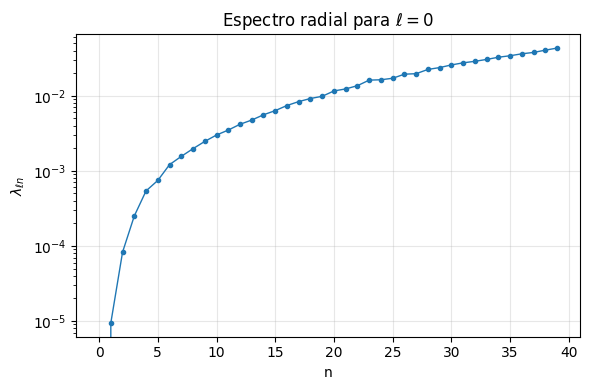

In [74]:
# Parámetros base
Rs   = 2.0
rmin = 0.0
rmax = 600.0
Nr   = 5000

ell     = 0
n_modes = 40

r, lam, e, M = solve_basis_uniform(rmin, rmax, Nr, Rs, ell, n_modes)

print("Primeros eigenvalores:")
for i in range(min(10, n_modes)):
    print(f"n={i:2d}  lambda={lam[i]:.8e}  k={np.sqrt(lam[i]):.6f}")


# Eigenvalores
plt.figure(figsize=(6,4))
plt.plot(np.arange(n_modes), lam, marker="o", ms=3, lw=1)
plt.yscale("log")
plt.xlabel("n")
plt.ylabel(r"$\lambda_{\ell n}$")
plt.title(fr"Espectro radial para $\ell={ell}$")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


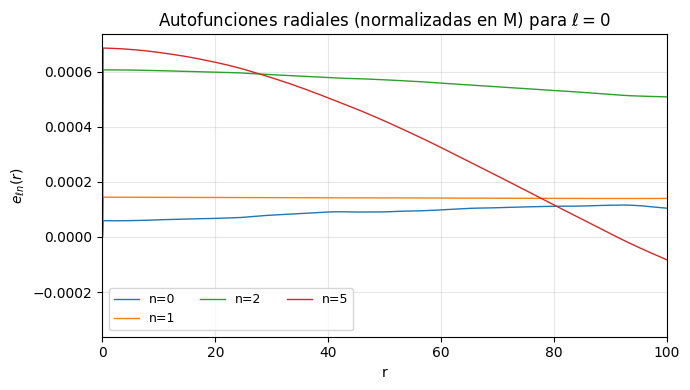

In [ ]:

# Algunas eigenfunciones
plt.figure(figsize=(7,4))
for n in [0, 1, 2, 5]:
    if n < n_modes:
        plt.plot(r, e[:, n], lw=1, label=f"n={n}")
plt.xlabel("r")
plt.xlim(rmin, 2)
plt.ylabel(r"$e_{\ell n}(r)$")
plt.title(fr"Autofunciones radiales (normalizadas en M) para $\ell={ell}$")
plt.legend(ncol=3, fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Chequeo ortogonalidad (M):
  min(diag) = 0.9999999999999996
  max(diag) = 1.0000000000000004
  max(|offdiag|) = 6.305719835175694e-16


/tmp/ipykernel_74001/3198156078.py:3: RuntimeWarning: divide by zero encountered in divide
  return 1.0 + Rs / r
/tmp/ipykernel_74001/3198156078.py:9: RuntimeWarning: invalid value encountered in multiply
  return r**2 * np.sqrt(A_of_r(r, Rs))   # w=r^2*sqrt(A)
/tmp/ipykernel_74001/3198156078.py:12: RuntimeWarning: invalid value encountered in divide
  return ell * (ell + 1.0) / (r**2)      # q=ell(ell+1)/r^2


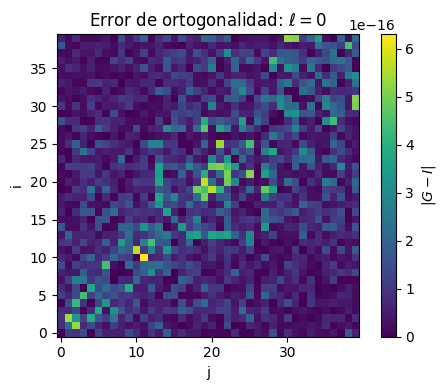

In [76]:
def mass_gram_matrix(rmin, rmax, Nr, Rs, ell, n_modes):
    r, lam, e, M = solve_basis_uniform(rmin, rmax, Nr, Rs, ell, n_modes)
    # E solo en dofs interiores (quitamos el Dirichlet en rmin)
    E = e[1:, :]  # (Nr-1, n_modes)
    G = E.T @ (M @ E)  # (n_modes, n_modes)
    return r, lam, e, G

r, lam, e, G = mass_gram_matrix(rmin, rmax, Nr, Rs, ell, n_modes)

diag = np.diag(G)
off  = G - np.diag(diag)

print("Chequeo ortogonalidad (M):")
print("  min(diag) =", diag.min())
print("  max(diag) =", diag.max())
print("  max(|offdiag|) =", np.max(np.abs(off)))

plt.figure(figsize=(5,4))
plt.imshow(np.abs(G - np.eye(n_modes)), origin="lower")
plt.colorbar(label=r"$|G - I|$")
plt.title(fr"Error de ortogonalidad: $\ell={ell}$")
plt.xlabel("j")
plt.ylabel("i")
plt.tight_layout()
plt.show()



/tmp/ipykernel_74001/3198156078.py:3: RuntimeWarning: divide by zero encountered in divide
  return 1.0 + Rs / r
/tmp/ipykernel_74001/3198156078.py:9: RuntimeWarning: invalid value encountered in multiply
  return r**2 * np.sqrt(A_of_r(r, Rs))   # w=r^2*sqrt(A)
/tmp/ipykernel_74001/3198156078.py:12: RuntimeWarning: invalid value encountered in divide
  return ell * (ell + 1.0) / (r**2)      # q=ell(ell+1)/r^2
/tmp/ipykernel_74001/2739635631.py:7: RuntimeWarning: invalid value encountered in sqrt
  plt.plot(np.sqrt(lam), marker="o", ms=3, lw=1, label=fr"$\ell={ell}$")
/tmp/ipykernel_74001/3198156078.py:12: RuntimeWarning: divide by zero encountered in divide
  return ell * (ell + 1.0) / (r**2)      # q=ell(ell+1)/r^2


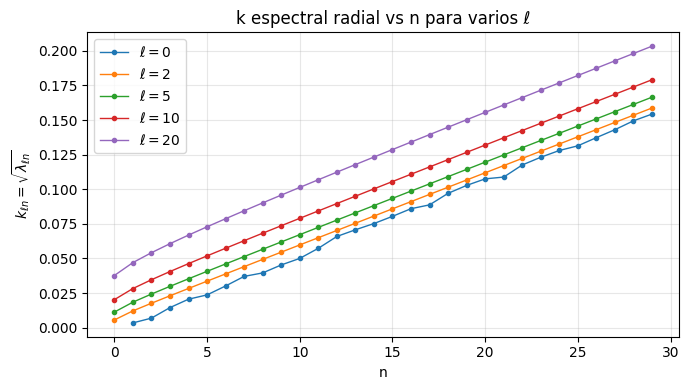

In [77]:
ells = [0, 2, 5, 10, 20]
n_modes = 30

plt.figure(figsize=(7,4))
for ell in ells:
    r, lam, e, M = solve_basis_uniform(rmin, rmax, Nr, Rs, ell, n_modes)
    plt.plot(np.sqrt(lam), marker="o", ms=3, lw=1, label=fr"$\ell={ell}$")
plt.xlabel("n")
plt.ylabel(r"$k_{\ell n}=\sqrt{\lambda_{\ell n}}$")
plt.title("k espectral radial vs n para varios ℓ")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
ell_max = 80      # puedes empezar con 30; sube después (60, 80, 120...)
n_modes = 160      # igual que tu celda actual (luego subirás a 80–120)

lam_list = []
e_list   = []
M_list   = []   # guardo M por si quieres chequear ortogonalidad por ℓ
r_grid = None

for ell in range(ell_max + 1):
    r, lam, e, M = solve_basis_uniform(rmin, rmax, Nr, Rs, ell, n_modes)
    if r_grid is None:
        r_grid = r
    lam_list.append(lam)
    e_list.append(e)
    M_list.append(M)

print("Listo: lam_list y e_list construidas.")
print("r_grid:", r_grid[0], "->", r_grid[-1], "Nr=", r_grid.size)
print("ell_max=", ell_max, "n_modes=", n_modes)


/tmp/ipykernel_74001/3198156078.py:3: RuntimeWarning: divide by zero encountered in divide
  return 1.0 + Rs / r
/tmp/ipykernel_74001/3198156078.py:9: RuntimeWarning: invalid value encountered in multiply
  return r**2 * np.sqrt(A_of_r(r, Rs))   # w=r^2*sqrt(A)
/tmp/ipykernel_74001/3198156078.py:12: RuntimeWarning: invalid value encountered in divide
  return ell * (ell + 1.0) / (r**2)      # q=ell(ell+1)/r^2
/tmp/ipykernel_74001/3198156078.py:12: RuntimeWarning: divide by zero encountered in divide
  return ell * (ell + 1.0) / (r**2)      # q=ell(ell+1)/r^2


In [ ]:
def check_orthogonality_for_ell(e, M, ncheck=None):
    # e: (Nr, n_modes), con e[0]=0 por Dirichlet
    # M: (Nr-1, Nr-1) sobre los dofs interiores
    E = e[1:, :]  # quita nodo Dirichlet
    if ncheck is not None:
        E = E[:, :ncheck]
    G = E.T @ (M @ E)
    diag = np.diag(G)
    off = G - np.diag(diag)
    return diag, off, G

for ell in [0, 10, min(ell_max, 20)]:
    diag, off, G = check_orthogonality_for_ell(e_list[ell], M_list[ell], ncheck=n_modes)
    print(f"ℓ={ell}: min(diag)={diag.min():.16f}, max(diag)={diag.max():.16f}, max|off|={np.max(np.abs(off)):.3e}")


ℓ=0: min(diag)=0.9999999999999996, max(diag)=1.0000000000000004, max|off|=4.597e-16
ℓ=10: min(diag)=0.9999999999999994, max(diag)=1.0000000000000007, max|off|=3.955e-16
ℓ=20: min(diag)=0.9999999999999996, max(diag)=1.0000000000000009, max|off|=3.608e-16


/tmp/ipykernel_74001/2988847842.py:3: RuntimeWarning: invalid value encountered in sqrt
  K[ell, :] = np.sqrt(lam_list[ell])


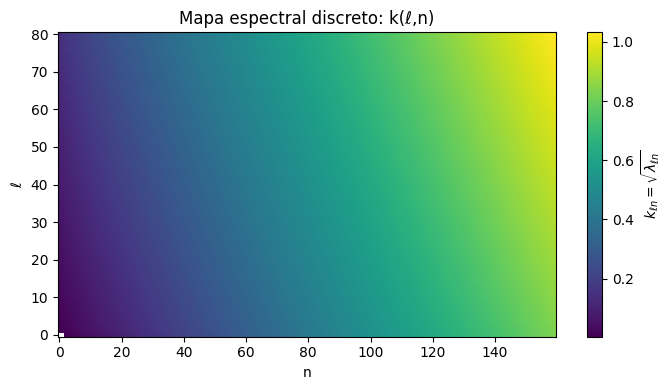

In [ ]:
K = np.zeros((ell_max+1, n_modes), dtype=float)
for ell in range(ell_max+1):
    K[ell, :] = np.sqrt(lam_list[ell])

# heatmap (ell,n) -> k
plt.figure(figsize=(7,4))
plt.imshow(K, origin="lower", aspect="auto")
plt.colorbar(label=r"$k_{\ell n}=\sqrt{\lambda_{\ell n}}$")
plt.xlabel("n")
plt.ylabel(r"$\ell$")
plt.title("Mapa espectral discreto: k(ℓ,n)")
plt.tight_layout()
plt.show()


sigma_k = 0.1
k_cut   = 0.5
modos activos (ell,n): 6237 de 12960


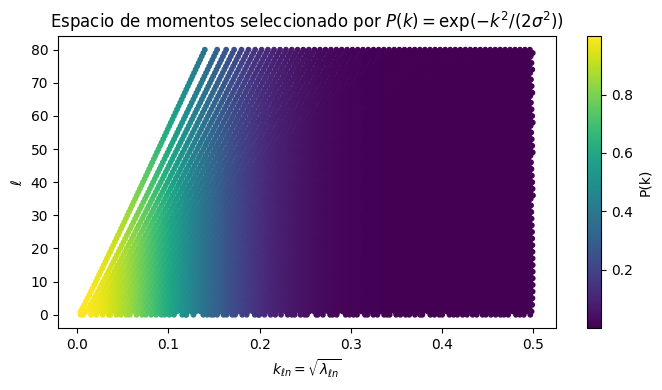

In [ ]:
sigma_k = 0.1      # ancho del filtro en k (ajusta)
N_sigma = 5.0       # corte práctico: k_cut = N_sigma*sigma_k
k_cut = N_sigma * sigma_k

P = np.exp(-(K**2) / (2.0*sigma_k**2))
mask = (K <= k_cut)

print("sigma_k =", sigma_k)
print("k_cut   =", k_cut)
print("modos activos (ell,n):", int(mask.sum()), "de", (ell_max+1)*n_modes)

# nube (k, ell) coloreada por P(k)
ells_flat = np.repeat(np.arange(ell_max+1), n_modes)
k_flat = K.reshape(-1)
p_flat = P.reshape(-1)
m_flat = mask.reshape(-1)

plt.figure(figsize=(7,4))
plt.scatter(k_flat[m_flat], ells_flat[m_flat], s=10, c=p_flat[m_flat], rasterized=True)
plt.xlabel(r"$k_{\ell n}=\sqrt{\lambda_{\ell n}}$")
plt.ylabel(r"$\ell$")
plt.title(r"Espacio de momentos seleccionado por $P(k)=\exp(-k^2/(2\sigma^2))$")
cb = plt.colorbar()
cb.set_label("P(k)")
plt.tight_layout()
plt.show()


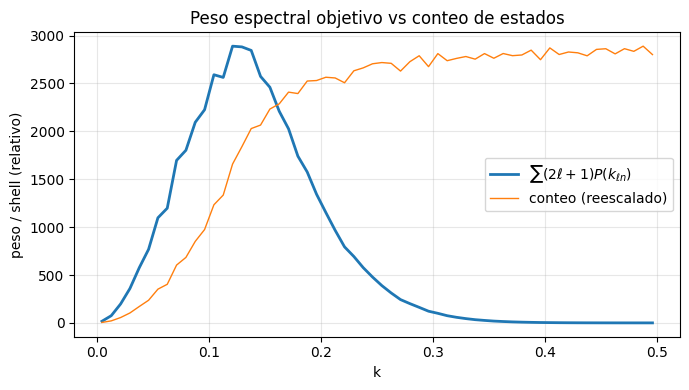

In [ ]:
nbins = 60
bins = np.linspace(0.0, max(k_cut, K.max()), nbins+1)
centers = 0.5*(bins[:-1] + bins[1:])

N_shell = np.zeros(nbins)   # conteo con degeneración
W_shell = np.zeros(nbins)   # peso objetivo sum (2ℓ+1) P(k)

for ell in range(ell_max+1):
    deg = 2*ell + 1
    for n in range(n_modes):
        if not mask[ell, n]:
            continue
        j = np.digitize(K[ell, n], bins) - 1
        if 0 <= j < nbins:
            N_shell[j] += deg
            W_shell[j] += deg * P[ell, n]

plt.figure(figsize=(7,4))
plt.plot(centers, W_shell, lw=2, label=r"$\sum (2\ell+1)P(k_{\ell n})$")
plt.plot(centers, (N_shell / (N_shell.max()+1e-300))*W_shell.max(), lw=1, label="conteo (reescalado)")
plt.xlabel("k")
plt.ylabel("peso / shell (relativo)")
plt.title("Peso espectral objetivo vs conteo de estados")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
def sample_a_coeff(ell_max, n_modes, P, mask, seed=0):
    rng = np.random.default_rng(seed)
    a_coeff = {}
    for ell in range(ell_max+1):
        amp = np.sqrt(P[ell, :]) * mask[ell, :]  # (n_modes,)
        for m in range(-ell, ell+1):
            z = (rng.standard_normal(n_modes) + 1j*rng.standard_normal(n_modes))/np.sqrt(2.0)
            a_coeff[(ell, m)] = amp * z
    return a_coeff

seed = 123
a_coeff = sample_a_coeff(ell_max, n_modes, P, mask, seed=seed)


def sample_a_coeff(ell_max, n_modes, P, mask, seed=0):
    rng = np.random.default_rng(seed)
    a_coeff = {}
    for ell in range(ell_max+1):
        amp = np.sqrt(P[ell, :]) * mask[ell, :]  # (n_modes,)
        for m in range(-ell, ell+1):
            z = (rng.standard_normal(n_modes) + 1j*rng.standard_normal(n_modes))/np.sqrt(2.0)
            a_coeff[(ell, m)] = amp * z
    return a_coeff

seed = 123
a_coeff = sample_a_coeff(ell_max, n_modes, P, mask, seed=seed)



In [ ]:
from scipy.special import sph_harm

def eval_field_xy(X, Y, r_grid, e_list, a_coeff, ell_max, n_modes):
    """
    f(x,y) complejo en el plano z=0.
    Usa: r = sqrt(x^2+y^2), theta = pi/2, phi = atan2(y,x).
    """
    X = np.asarray(X, float)
    Y = np.asarray(Y, float)
    assert X.shape == Y.shape

    r = np.sqrt(X*X + Y*Y)
    theta = np.full_like(r, np.pi/2)
    phi = np.arctan2(Y, X) % (2*np.pi)

    rmin, rmax = float(r_grid[0]), float(r_grid[-1])
    inside = (r >= rmin) & (r <= rmax)

    f = np.zeros_like(r, dtype=np.complex128)

    r_flat  = r[inside].ravel()
    th_flat = theta[inside].ravel()
    ph_flat = phi[inside].ravel()

    for ell in range(ell_max+1):
        # interpola tabla radial E_flat para este ell
        E_flat = np.empty((r_flat.size, n_modes), dtype=float)
        e_tab = e_list[ell][:, :n_modes]  # (Nr,n_modes)
        for n in range(n_modes):
            E_flat[:, n] = np.interp(r_flat, r_grid, e_tab[:, n])

        for m in range(-ell, ell+1):
            a_m = a_coeff[(ell, m)]          # (n_modes,)
            u_flat = E_flat @ a_m            # (Npts,)
            Y_flat = sph_harm(m, ell, ph_flat, th_flat)
            f[inside] += (u_flat * Y_flat).reshape(f[inside].shape)

    return f


/tmp/ipykernel_74001/4011743421.py:35: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  Y_flat = sph_harm(m, ell, ph_flat, th_flat)


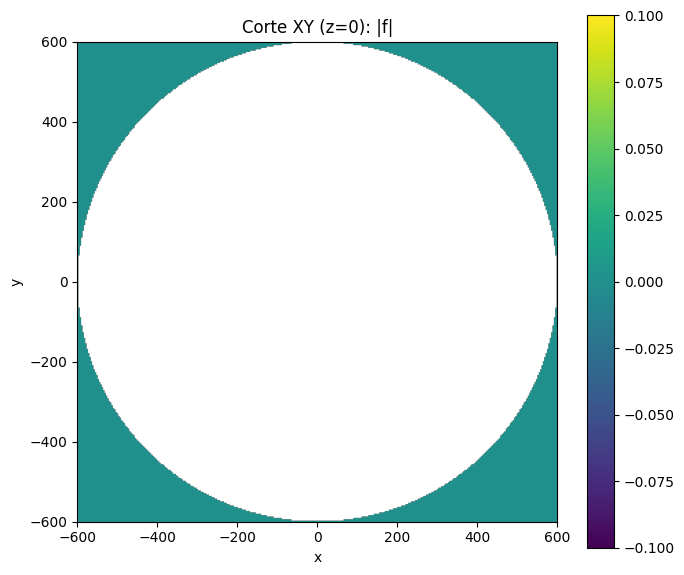

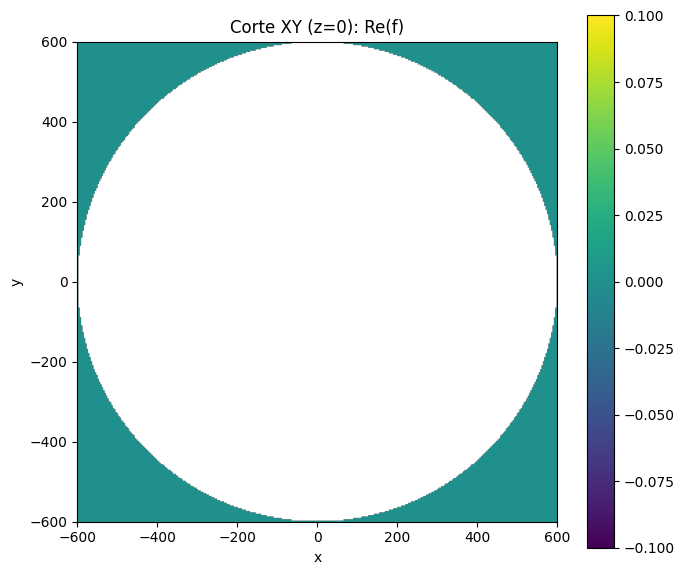

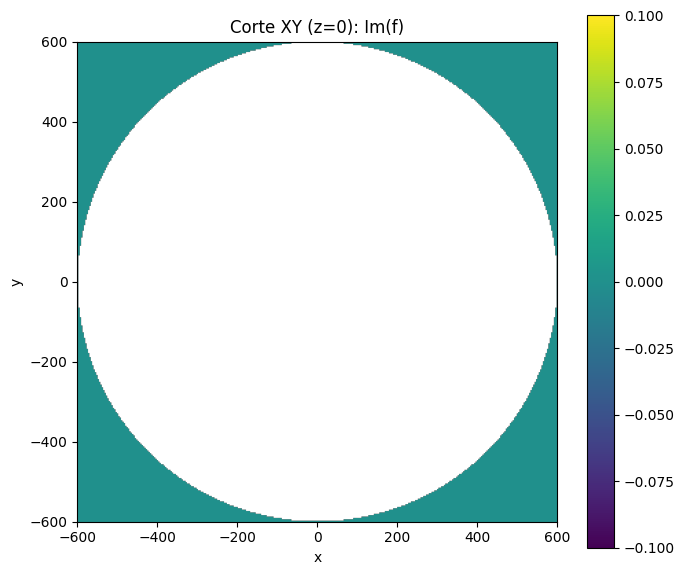

In [ ]:
# Grilla para graficar
Rplot = rmax  # puedes bajar a 400 para ver interior sin borde
Nxy = 350
x = np.linspace(-Rplot, Rplot, Nxy)
y = np.linspace(-Rplot, Rplot, Nxy)
X, Y = np.meshgrid(x, y, indexing="xy")

Fxy = eval_field_xy(X, Y, r_grid, e_list, a_coeff, ell_max, n_modes)

# Plots
for title, img in [("|f|", np.abs(Fxy)), ("Re(f)", Fxy.real), ("Im(f)", Fxy.imag)]:
    plt.figure(figsize=(7,6))
    plt.imshow(img, origin="lower", extent=[x.min(), x.max(), y.min(), y.max()], aspect="equal")
    plt.xlabel("x"); plt.ylabel("y")
    plt.title(f"Corte XY (z=0): {title}")
    plt.colorbar()
    plt.tight_layout()
    plt.show()


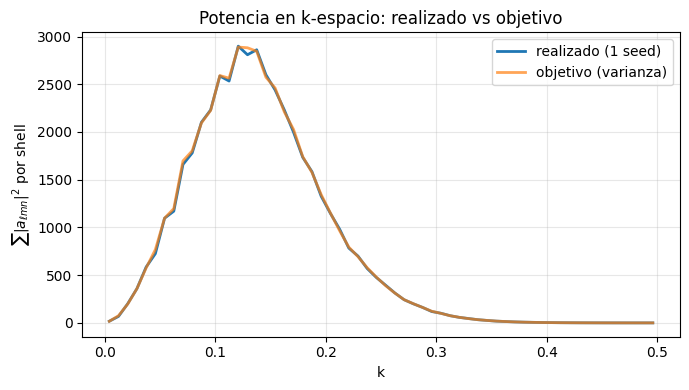

In [ ]:
def shell_power_realized(a_coeff, K, mask, ell_max, n_modes, bins):
    nb = len(bins)-1
    E = np.zeros(nb, dtype=float)
    for ell in range(ell_max+1):
        k_ell = K[ell, :]
        n_idx = np.where(mask[ell, :])[0]
        for m in range(-ell, ell+1):
            a = a_coeff[(ell, m)]
            for n in n_idx:
                j = np.digitize(k_ell[n], bins) - 1
                if 0 <= j < nb:
                    E[j] += (a[n].real*a[n].real + a[n].imag*a[n].imag)
    return E

nbins = 60
bins = np.linspace(0.0, max(k_cut, K.max()), nbins+1)
centers = 0.5*(bins[:-1] + bins[1:])

E_real = shell_power_realized(a_coeff, K, mask, ell_max, n_modes, bins)

plt.figure(figsize=(7,4))
plt.plot(centers, E_real, lw=2, label="realizado (1 seed)")
plt.plot(centers, W_shell, lw=2, alpha=0.7, label="objetivo (varianza)")
plt.xlabel("k"); plt.ylabel(r"$\sum |a_{\ell m n}|^2$ por shell")
plt.title("Potencia en k-espacio: realizado vs objetivo")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import os

# ============================================================
# Geometría EF-Schwarzschild
# ============================================================

def A_of_r(r, Rs):
    return 1.0 + Rs / r

def p_of_r(r, Rs):
    return r**2 / np.sqrt(A_of_r(r, Rs))

def w_of_r(r, Rs):
    return r**2 * np.sqrt(A_of_r(r, Rs))

def q_of_r(r, ell):
    return ell * (ell + 1.0) / (r**2)


# ============================================================
# Construcción matrices
# ============================================================

def build_matrices_uniform(rmin, rmax, Nr, Rs, ell, kappa=None):
    r = np.linspace(rmin, rmax, Nr)
    dr = (rmax - rmin) / (Nr - 1)

    if kappa is None:
        kappa = (ell + 1.0) / rmax

    p = p_of_r(r, Rs)
    w = w_of_r(r, Rs)
    q = q_of_r(r, ell)

    p_face = 2.0 * p[:-1] * p[1:] / (p[:-1] + p[1:] + 1e-300)
    coeff = p_face / dr

    main = np.zeros(Nr)
    off  = np.zeros(Nr - 1)

    main[:-1] += coeff
    main[1:]  += coeff
    off[:]    -= coeff

    K = sp.diags([off, main, off], offsets=[-1, 0, 1], format="csr")

    M = sp.diags(w * dr, 0, format="csr")
    V = sp.diags(w * q * dr, 0, format="csr")

    keep = np.arange(1, Nr)
    K = K[keep][:, keep]
    M = M[keep][:, keep]
    V = V[keep][:, keep]

    p_rmax = float(p[-1])
    ndof = K.shape[0]
    K = K + sp.diags([p_rmax * kappa], [ndof - 1], shape=K.shape, format="csr")

    return r, dr, (K + V).tocsr(), M.tocsr()


def solve_basis_uniform(rmin, rmax, Nr, Rs, ell, n_modes):

    r, dr, Aop, M = build_matrices_uniform(rmin, rmax, Nr, Rs, ell)

    evals, evecs = spla.eigsh(Aop, k=n_modes, M=M, sigma=0.0, which="LM")

    idx = np.argsort(evals)
    evals = evals[idx]
    evecs = evecs[:, idx]

    # Normalización M
    for j in range(n_modes):
        norm2 = float(evecs[:, j].T @ (M @ evecs[:, j]))
        evecs[:, j] /= np.sqrt(norm2 + 1e-300)

    modes = np.zeros((Nr, n_modes), dtype=np.float64)
    modes[1:, :] = evecs.real

    return r, evals, modes


# ============================================================
# Guardado ASCII
# ============================================================

def save_ascii_ell(output_dir, ell, r, lam, R):
    Nr, Nm = R.shape

    filename = os.path.join(output_dir, f"sl_basis_ell_{ell:03d}.dat")

    with open(filename, "w") as f:
        f.write(f"{Nr} {Nm}\n")

        # lambda
        for val in lam:
            f.write(f"{val:.16e} ")
        f.write("\n")

        # matriz R
        for i in range(Nr):
            for j in range(Nm):
                f.write(f"{R[i,j]:.16e} ")
            f.write("\n")

    print(f"Guardado: {filename}")


# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":

    # ---------------- Parámetros ----------------
    rmin = 0.0
    rmax = 600.8
    Nr = 8000
    Rs = 0.5
    ell_max = 2
    n_modes = Nr//2

    print(n_modes, "modos por ℓ")

    output_dir = "sl_basis_ascii"
    os.makedirs(output_dir, exist_ok=True)

    print("Iniciando precomputación...\n")

    for ell in range(11,ell_max + 1):
        print(f"ℓ = {ell}")

        r, lam, R = solve_basis_uniform(
            rmin, rmax, Nr, Rs, ell, n_modes
        )

        save_ascii_ell(output_dir, ell, r, lam, R)

    print("\nTodo terminado correctamente.")


4000 modos por ℓ
Iniciando precomputación...


Todo terminado correctamente.


In [ ]:
# %% [markdown]
# # Migración SL ASCII → NPZ (no elimina ASCII)
# - Convierte solo archivos que no estén ya en formato binario
# - No recalcula nada
# - Guarda lam y R en formato binario rápido

# %%
import os
import numpy as np
import time

BASIS_DIR_ASCII = "sl_basis_ascii"
BASIS_DIR_NPZ   = "sl_basis_npz"
ELL_MAX         = 80

os.makedirs(BASIS_DIR_NPZ, exist_ok=True)

def load_sl_basis_ascii(path: str):
    with open(path, "r") as f:
        Nr, Nm = map(int, f.readline().split())
        lam = np.array(list(map(float, f.readline().split())), dtype=np.float64)
        R = np.empty((Nr, Nm), dtype=np.float64)
        for i in range(Nr):
            R[i, :] = np.fromstring(f.readline(), sep=" ", dtype=np.float64)
    return lam, R

t0 = time.time()
converted = 0
skipped   = 0

for ell in range(ELL_MAX + 1):
    src = os.path.join(BASIS_DIR_ASCII, f"sl_basis_ell_{ell:03d}.dat")
    dst = os.path.join(BASIS_DIR_NPZ,   f"sl_basis_ell_{ell:03d}.npz")

    if not os.path.exists(src):
        continue

    if os.path.exists(dst):
        skipped += 1
        continue

    lam, R = load_sl_basis_ascii(src)

    # Guardado binario rápido (sin compresión)
    np.savez(dst, lam=lam, R=R)

    converted += 1

t1 = time.time()

print(f"[INFO] Convertidos: {converted}")
print(f"[INFO] Ya existentes: {skipped}")
print(f"[INFO] Tiempo total: {t1 - t0:.2f} s")
print(f"[INFO] Archivos binarios en: {BASIS_DIR_NPZ}")

[INFO] Convertidos: 0
[INFO] Ya existentes: 0
[INFO] Tiempo total: 0.00 s
[INFO] Archivos binarios en: sl_basis_npz


In [ ]:
import os
import numpy as np

BASIS_DIR_NPZ = "sl_basis_npz"
BASIS_DIR_NPY = "sl_basis_npy"
ELL_MAX = 80

os.makedirs(BASIS_DIR_NPY, exist_ok=True)

for ell in range(ELL_MAX + 1):
    src = os.path.join(BASIS_DIR_NPZ, f"sl_basis_ell_{ell:03d}.npz")
    if not os.path.exists(src):
        continue

    out_lam = os.path.join(BASIS_DIR_NPY, f"sl_basis_ell_{ell:03d}_lam.npy")
    out_R   = os.path.join(BASIS_DIR_NPY, f"sl_basis_ell_{ell:03d}_R.npy")

    if os.path.exists(out_lam) and os.path.exists(out_R):
        continue

    with np.load(src) as z:
        lam = z["lam"].astype(np.float64, copy=False)
        R   = z["R"].astype(np.float64, copy=False)

    # NPY: binario directo, muy fácil de leer desde Fortran
    np.save(out_lam, lam, allow_pickle=False)
    np.save(out_R,   R,   allow_pickle=False)

print("[INFO] Listo. Archivos NPY en:", BASIS_DIR_NPY)

[INFO] Listo. Archivos NPY en: sl_basis_npy


In [ ]:
import numpy as np
p = "/home/flavio/Codes/KG-Y/sl_basis_npy/sl_basis_ell_000_R.npy"
R = np.load(p)
print(R.shape, R.dtype, R.flags["F_CONTIGUOUS"], R.flags["C_CONTIGUOUS"])

FileNotFoundError: [Errno 2] No such file or directory: '/home/flavio/Codes/KG-Y/sl_basis_npy/sl_basis_ell_000_R.npy'

[INFO] ells con datos: 81/81


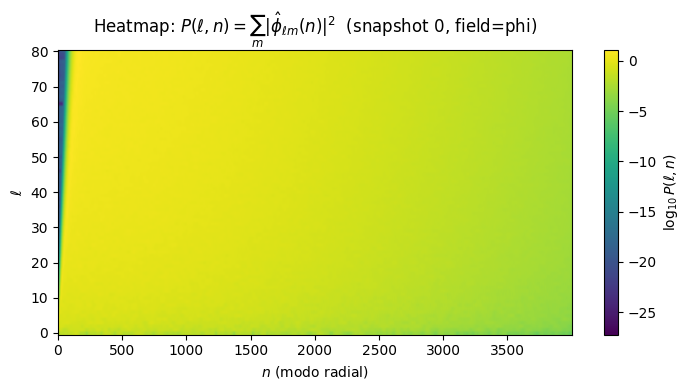

[INFO] snapshot=0 field=phi ell=0..80 Nm_global=4000
[INFO] k-range auto: 0.30342313486668043 18.733929545909835
[INFO] bins no vacíos: 100 / 100


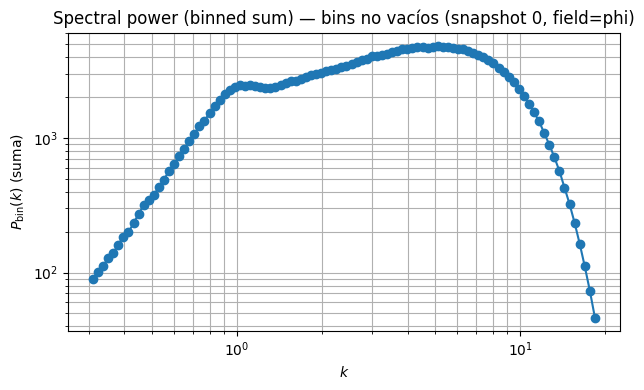

In [ ]:
# %% [markdown]
# # SL spectral power (1 snapshot) — 1 proceso + BLAS multihilo (8) + RAM estable
# - Proyección por ell con GEMM grande
# - Pre-pesado de base: Rw = weights * R
# - Carga/usa/libera por ell (sin cache global de bases)

# %%
import numpy as np
import h5py, os, re, gc
import matplotlib.pyplot as plt
from threadpoolctl import threadpool_limits

# ------------------ Config ------------------
MODES_H5   = "m21_sigma_5/modes.h5"
BASIS_DIR  = "sl_basis_ascii"
SNAPSHOT   = 0
ELL_MAX    = 80
RS         = 0.5
FIELD_NAME = "phi"

RMIN, RMAX, NR = 0.8, 600.8, 8000
NBINS = 100

MODE_RE = re.compile(r"^mode_(\d+)$")

# ------------------ Geometría/pesos ------------------
def A_of_r(r, Rs): 
    return 1.0 + Rs/r

def w_of_r(r, Rs): 
    return r**2 * np.sqrt(A_of_r(r, Rs))

r  = np.linspace(RMIN, RMAX, NR)
dr = (RMAX - RMIN) / (NR - 1)
weights = np.ascontiguousarray(w_of_r(r, RS) * dr, dtype=np.float64)

# ------------------ n <-> (ell,m) ------------------
def n_to_ellm(n: int):
    ell = int(np.sqrt(n))
    rr  = n - ell*ell
    m   = int(rr) - ell
    return ell, m

def load_sl_basis_npz(basis_dir: str, ell: int):
    path = os.path.join(basis_dir, f"sl_basis_ell_{ell:03d}.npz")
    z = np.load(path)
    lam = z["lam"]
    R   = z["R"]
    return lam, R



# %%
# ------------------ Agrupar modos por ell (1 pasada) ------------------
with h5py.File(MODES_H5, "r") as h5:
    mode_names = [k for k in h5.keys() if MODE_RE.match(k)]
mode_names.sort()

modes_by_ell = {ell: [] for ell in range(ELL_MAX + 1)}
for gname in mode_names:
    n_lin = int(MODE_RE.match(gname).group(1))
    ell, m = n_to_ellm(n_lin)
    if 0 <= ell <= ELL_MAX:
        modes_by_ell[ell].append((m, gname))

ells_with_data = [ell for ell in range(ELL_MAX + 1) if modes_by_ell[ell]]
print(f"[INFO] ells con datos: {len(ells_with_data)}/{ELL_MAX+1}")

# %%
# =========================================================
# PARTE 1: P(ell,n) = sum_m |a_{ell m n}|^2  (rápido)
# =========================================================
P_ell = {}
k_ell_map = {}

# Limita BLAS a 8 hilos (núcleos físicos)
with threadpool_limits(limits=8):
    with h5py.File(MODES_H5, "r") as h5:
        for ell in range(ELL_MAX + 1):
            items = modes_by_ell.get(ell, [])
            if not items:
                continue
            items.sort(key=lambda x: x[0])
            n_m = len(items)

            lam, R = load_sl_basis_npz("sl_basis_npz", ell)
            
            if R.shape[0] != NR:
                raise RuntimeError(f"NR inconsistente en base ell={ell}: {R.shape[0]} vs {NR}")

            # k y base pre-pesada
            k_ell = np.sqrt(np.maximum(lam, 0.0))
            Rw = np.ascontiguousarray(R * weights[:, None], dtype=np.float64)  # (Nr,Nm)

            # lee TODOS los m (GEMM grande)
            Phi = np.empty((NR, n_m), dtype=np.complex128)
            for j, (m, gname) in enumerate(items):
                arr = h5[gname][FIELD_NAME][:, :, SNAPSHOT]  # (2,Nr)
                Phi[:, j] = arr[0, :] + 1j * arr[1, :]

            # proyección y potencia
            A  = Rw.T @ np.conjugate(Phi)          # (Nm,n_m)
            Pn = np.sum(np.abs(A)**2, axis=1)      # (Nm,)

            P_ell[ell] = Pn.astype(np.float64)
            k_ell_map[ell] = k_ell

            # liberar por ell (RAM estable)
            del lam, R, Rw, Phi, A, Pn
            gc.collect()

# %%
# ------------------ Armar matrices P_ln y k_ln ------------------
Nm_global = max(P_ell[ell].shape[0] for ell in P_ell.keys())
P_ln = np.full((ELL_MAX + 1, Nm_global), np.nan, dtype=np.float64)
k_ln = np.full((ELL_MAX + 1, Nm_global), np.nan, dtype=np.float64)

for ell, Pn in P_ell.items():
    nloc = Pn.shape[0]
    P_ln[ell, :nloc] = Pn
    k_ln[ell, :nloc] = k_ell_map[ell][:nloc]

# %%
# ------------------ Heatmap ------------------
plt.figure(figsize=(7.2, 4.0))
plt.imshow(np.log10(P_ln + 1e-300), origin="lower", aspect="auto")
plt.colorbar(label=r"$\log_{10} P(\ell,n)$")
plt.xlabel(r"$n$ (modo radial)")
plt.ylabel(r"$\ell$")
plt.title(
    rf"Heatmap: $P(\ell,n)=\sum_m|\hat{{\phi}}_{{\ell m}}(n)|^2$  (snapshot {SNAPSHOT}, field={FIELD_NAME})"
)
plt.tight_layout()
plt.show()

# %%
# =========================================================
# PARTE 2: binning en k — bins no vacíos
# =========================================================
finite = np.isfinite(k_ln) & np.isfinite(P_ln)
k_all = k_ln[finite].ravel()
P_all = P_ln[finite].ravel()

k_pos = k_all[k_all > 0]
kmin = np.percentile(k_pos, 1)
kmax = np.percentile(k_pos, 99)

k_edges   = np.logspace(np.log10(kmin), np.log10(kmax), NBINS + 1)
k_centers = np.sqrt(k_edges[:-1] * k_edges[1:] )

idx = np.searchsorted(k_edges, k_all, side="right") - 1
valid = (idx >= 0) & (idx < NBINS) & np.isfinite(P_all)

P_bin = np.zeros(NBINS, dtype=np.float64)
N_bin = np.zeros(NBINS, dtype=np.int64)
np.add.at(P_bin, idx[valid], P_all[valid])
np.add.at(N_bin, idx[valid], 1)

mask = N_bin > 0

print(f"[INFO] snapshot={SNAPSHOT} field={FIELD_NAME} ell=0..{ELL_MAX} Nm_global={Nm_global}")
print("[INFO] k-range auto:", kmin, kmax)
print("[INFO] bins no vacíos:", int(mask.sum()), "/", NBINS)

plt.figure(figsize=(6.4, 4.0))
plt.loglog(k_centers[mask], P_bin[mask], marker="o", linestyle="-")
plt.xlabel(r"$k$")
plt.ylabel(r"$P_{\rm bin}(k)$ (suma)")
plt.title(f"Spectral power (binned sum) — bins no vacíos (snapshot {SNAPSHOT}, field={FIELD_NAME})")
plt.grid(True, which="both")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import h5py, os, re, gc
import matplotlib.pyplot as plt

# ------------------ Config ------------------
MODES_H5   = "5m20_sigma_1/modes.h5"
BASIS_DIR  = "sl_basis_npz"
OUT_DIR    = "5m20_sigma_1/spectra_all_times"
FIELD_NAME = "phi"

RMIN, RMAX, NR = 0.8, 600.8, 8000
RS = 0.5

NBINS = 35
T_FACTOR = 5.0
ELL_MAX = 80
TBLOCK = 8

EPS = 1e-300

MODE_RE = re.compile(r"^mode_(\d+)$")

# ------------------ Geometría/pesos ------------------
def A_of_r(r, Rs): return 1.0 + Rs/r
def w_of_r(r, Rs): return r**2 * np.sqrt(A_of_r(r, Rs))

r  = np.linspace(RMIN, RMAX, NR)
dr = (RMAX - RMIN) / (NR - 1)
weights = (w_of_r(r, RS) * dr).astype(np.float64, copy=False)

# ------------------ n <-> (ell,m) ------------------
def n_to_ellm(n: int):
    ell = int(np.sqrt(n))
    rr  = n - ell*ell
    m   = int(rr) - ell
    return ell, m

# ------------------ Leer base SL NPZ ------------------
def load_sl_basis_npz(basis_dir: str, ell: int):
    path = os.path.join(basis_dir, f"sl_basis_ell_{ell:03d}.npz")
    z = np.load(path)
    lam = z["lam"].astype(np.float64, copy=False)
    R   = z["R"].astype(np.float64, copy=False)   # (Nr, Nm)
    return np.ascontiguousarray(lam), np.ascontiguousarray(R)

# ------------------ Salidas ------------------
heat_dir = os.path.join(OUT_DIR, "heatmap")
pk_dir   = os.path.join(OUT_DIR, "pk")
os.makedirs(heat_dir, exist_ok=True)
os.makedirs(pk_dir, exist_ok=True)

# =========================================================
# 1) Indexar modos en HDF5 y agrupar por ℓ (y m)
# =========================================================
with h5py.File(MODES_H5, "r") as h5:
    mode_names = [k for k in h5.keys() if MODE_RE.match(k)]
    mode_names.sort()
    if not mode_names:
        raise RuntimeError("No encontré grupos mode_XXXXX en el HDF5.")

    dset0 = h5[mode_names[0]][FIELD_NAME]
    if dset0.ndim != 3 or dset0.shape[0] != 2:
        raise RuntimeError(f"Dataset {FIELD_NAME} no tiene forma (2,Nr,Nt). Forma: {dset0.shape}")
    if dset0.shape[1] != NR:
        raise RuntimeError(f"NR inconsistente: HDF5 Nr={dset0.shape[1]} vs NR={NR}")
    Nt = int(dset0.shape[2])

ell_to_modes = {}
for gname in mode_names:
    n_lin = int(MODE_RE.match(gname).group(1))
    ell, m = n_to_ellm(n_lin)
    if (ELL_MAX is None) or (ell <= ELL_MAX):
        ell_to_modes.setdefault(ell, []).append((m, gname))

ells = sorted(ell_to_modes.keys())
for ell in ells:
    ell_to_modes[ell].sort(key=lambda x: x[0])

print(f"[INFO] Nt={Nt} | n_ell={len(ells)} | TBLOCK={TBLOCK}")

# =========================================================
# 2) Precompute por ℓ: k_ell y operador WRt = (R^T * weights)
# =========================================================
basis_cache = {}
Nm_ref = None

for ell in ells:
    lam, Rm = load_sl_basis_npz(BASIS_DIR, ell)
    if Rm.shape[0] != NR:
        raise RuntimeError(f"NR inconsistente en base ell={ell}: {Rm.shape[0]} vs {NR}")
    Nm = int(Rm.shape[1])
    if Nm_ref is None:
        Nm_ref = Nm
    elif Nm != Nm_ref:
        raise RuntimeError(f"Nm inconsistente: ell={ell} Nm={Nm} vs ref={Nm_ref}")

    k_ell = np.sqrt(np.maximum(lam, 0.0))
    WRt = np.ascontiguousarray(Rm.T * weights[None, :], dtype=np.float64)  # (Nm,Nr)

    basis_cache[ell] = {"k": k_ell, "WRt": WRt}
    del lam, Rm
    gc.collect()

# bins fijos
k_all_static = np.concatenate([basis_cache[ell]["k"] for ell in ells])
k_pos = k_all_static[k_all_static > 0]
kmin = np.percentile(k_pos, 1)
kmax = np.percentile(k_pos, 99)
k_edges   = np.logspace(np.log10(kmin), np.log10(kmax), NBINS + 1)
k_centers = np.sqrt(k_edges[:-1] * k_edges[1:])

k_all_flat = np.concatenate([basis_cache[ell]["k"] for ell in ells]).astype(np.float64, copy=False)
idx_bins = np.searchsorted(k_edges, k_all_flat, side="right") - 1
idx_valid = (idx_bins >= 0) & (idx_bins < NBINS)

# =========================================================
# Helper: construir P_ln_block para [s0,s1)
# =========================================================
def build_P_ln_block(h5, s0, s1):
    tblock = s1 - s0
    P_ln_block = np.zeros((len(ells), Nm_ref, tblock), dtype=np.float64)

    for iell, ell in enumerate(ells):
        WRt = basis_cache[ell]["WRt"]
        modes = ell_to_modes[ell]
        n_m = len(modes)

        Phi = np.empty((NR, n_m, tblock), dtype=np.complex128)
        for j, (_, gname) in enumerate(modes):
            arr = h5[gname][FIELD_NAME][:, :, s0:s1]  # (2,Nr,tblock)
            Phi[:, j, :] = arr[0, :, :] + 1j * arr[1, :, :]

        Phi2D = Phi.reshape(NR, n_m * tblock)
        A2D   = WRt @ np.conjugate(Phi2D)
        A     = A2D.reshape(Nm_ref, n_m, tblock)

        P_ln_block[iell, :, :] = np.sum(np.abs(A)**2, axis=1)

        del Phi, Phi2D, A2D, A
        gc.collect()

    return P_ln_block

# =========================================================
# PASADA 1: escalas globales (sin clip)
# =========================================================
global_hmin = +np.inf
global_hmax = -np.inf
global_pk_min = +np.inf
global_pk_max = -np.inf

# también guardaremos P(k) de primer y último snapshot
pk_first = None
pk_last  = None
s_first = 0
s_last  = Nt - 1

with h5py.File(MODES_H5, "r") as h5:
    for s0 in range(0, Nt, TBLOCK):
        s1 = min(s0 + TBLOCK, Nt)
        P_ln_block = build_P_ln_block(h5, s0, s1)

        for dt, s in enumerate(range(s0, s1)):
            P_ln = P_ln_block[:, :, dt]
            L = np.log10(P_ln + EPS)
            global_hmin = min(global_hmin, float(np.nanmin(L)))
            global_hmax = max(global_hmax, float(np.nanmax(L)))

            # P(k)
            P_flat = P_ln.reshape(-1).astype(np.float64, copy=False)
            P_bin = np.zeros(NBINS, dtype=np.float64)
            N_bin = np.zeros(NBINS, dtype=np.int64)

            v = idx_valid & np.isfinite(P_flat)
            np.add.at(P_bin, idx_bins[v], P_flat[v])
            np.add.at(N_bin, idx_bins[v], 1)
            mask = (N_bin > 0) & (P_bin > 0) & np.isfinite(P_bin)

            if np.any(mask):
                global_pk_min = min(global_pk_min, float(np.min(P_bin[mask])))
                global_pk_max = max(global_pk_max, float(np.max(P_bin[mask])))

            if s == s_first:
                pk_first = (P_bin.copy(), mask.copy())
            if s == s_last:
                pk_last  = (P_bin.copy(), mask.copy())

        print(f"[SCAN] {s0}..{s1-1} | heat=[{global_hmin:.3g},{global_hmax:.3g}] | pk=[{global_pk_min:.3g},{global_pk_max:.3g}]")
        del P_ln_block
        gc.collect()

if pk_first is None or pk_last is None:
    raise RuntimeError("No pude capturar P(k) de primer/último snapshot.")

HMIN, HMAX = global_hmin, global_hmax
PK_MIN, PK_MAX = global_pk_min, global_pk_max
print(f"[INFO] Heatmap fixed (log10): [{HMIN:.6g},{HMAX:.6g}]")
print(f"[INFO] P(k) fixed: [{PK_MIN:.6g},{PK_MAX:.6g}]")

# =========================================================
# PASADA 2: guardar figuras con escala fija
# =========================================================
with h5py.File(MODES_H5, "r") as h5:
    for s0 in range(0, Nt, TBLOCK):
        s1 = min(s0 + TBLOCK, Nt)
        P_ln_block = build_P_ln_block(h5, s0, s1)

        for dt, s in enumerate(range(s0, s1)):
            P_ln = P_ln_block[:, :, dt]
            P_flat = P_ln.reshape(-1).astype(np.float64, copy=False)

            # binning P(k)
            P_bin = np.zeros(NBINS, dtype=np.float64)
            N_bin = np.zeros(NBINS, dtype=np.int64)
            v = idx_valid & np.isfinite(P_flat)
            np.add.at(P_bin, idx_bins[v], P_flat[v])
            np.add.at(N_bin, idx_bins[v], 1)
            mask = (N_bin > 0) & (P_bin > 0) & np.isfinite(P_bin)

            # --- heatmap ---
            fig = plt.figure(figsize=(7.2, 4.0))
            plt.imshow(np.log10(P_ln + EPS), origin="lower", aspect="auto",
                       vmin=HMIN, vmax=HMAX)
            plt.colorbar(label=r"$\log_{10} P(\ell,n)$")
            plt.xlabel(r"$n$")
            plt.ylabel(r"$\ell$")
            plt.tight_layout()
            fig.savefig(os.path.join(heat_dir, f"P_ln_t{s:04d}.png"), dpi=150)
            plt.close(fig)

            # --- pk ---
            fig = plt.figure(figsize=(6.4, 4.0))
            plt.loglog(k_centers[mask], P_bin[mask], marker="o", linestyle="-")
            plt.xlabel(r"$k$")
            plt.ylabel(r"$P_{\rm bin}(k)$")
            plt.grid(True, which="both")
            plt.xlim(k_edges[0], k_edges[-1])
            plt.ylim(PK_MIN, PK_MAX)
            plt.tight_layout()
            fig.savefig(os.path.join(pk_dir, f"P_k_t{s:04d}.png"), dpi=150)
            plt.close(fig)

        print(f"[SAVE] {s0}..{s1-1}")
        del P_ln_block
        gc.collect()

# =========================================================
# Figura extra: primer y último instante juntos (solo P(k))
# =========================================================
P0, m0 = pk_first
P1, m1 = pk_last

fig = plt.figure(figsize=(6.8, 4.2))
plt.loglog(k_centers[m0], P0[m0], marker="o", linestyle="-", label=rf"$t={T_FACTOR*s_first:.1f}$")
plt.loglog(k_centers[m1], P1[m1], marker="o", linestyle="-", label=rf"$t={T_FACTOR*s_last:.1f}$")
plt.xlabel(r"$k$")
plt.ylabel(r"$P_{\rm bin}(k)$")
plt.grid(True, which="both")
plt.xlim(k_edges[0], k_edges[-1])
plt.ylim(PK_MIN, PK_MAX)
plt.legend()
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "Pk_first_last.png"), dpi=180)
plt.close(fig)

print(f"[OK] Frames en: {heat_dir} y {pk_dir}")
print(f"[OK] Comparación: {os.path.join(OUT_DIR, 'Pk_first_last.png')}")

[INFO] Nt=40 | n_ell=81 | TBLOCK=8
[SCAN] 0..7 | heat=[-28.2,0.902] | pk=[1.74e-05,4.22e+03]
[SCAN] 8..15 | heat=[-28.2,0.902] | pk=[1.74e-05,4.22e+03]
[SCAN] 16..23 | heat=[-28.2,0.902] | pk=[1.74e-05,4.22e+03]
[SCAN] 24..31 | heat=[-28.2,0.902] | pk=[1.74e-05,4.22e+03]
[SCAN] 32..39 | heat=[-28.2,0.902] | pk=[1.74e-05,4.22e+03]
[INFO] Heatmap fixed (log10): [-28.2187,0.902083]
[INFO] P(k) fixed: [1.7418e-05,4224.66]
[SAVE] 0..7
[SAVE] 8..15
[SAVE] 16..23
[SAVE] 24..31
[SAVE] 32..39
[OK] Frames en: 5m20_sigma_1/spectra_all_times/heatmap y 5m20_sigma_1/spectra_all_times/pk
[OK] Comparación: 5m20_sigma_1/spectra_all_times/Pk_first_last.png


k range: 0.000908029764033519 18.971799564855697


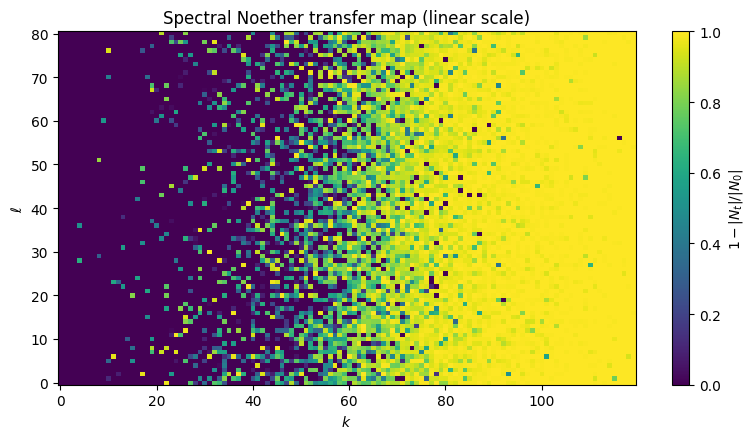

In [ ]:
# ============================================================
# Noether spectral transfer map (LINEAR SCALE)
# Observable:
#     F(ell,k) = 1 - |Nt(ell,k)| / |N0(ell,k)|
# Range forced to [0,1]
# ============================================================

import numpy as np
import h5py, os, re, gc
import matplotlib.pyplot as plt
from threadpoolctl import threadpool_limits

# ------------------ CONFIG ------------------
MODES_H5   = "/media/flavio/TOSHIBA EXT/rand_gaussian/m21_sigma_1/modes.h5"
BASIS_DIR  = "sl_basis_npz"

ELL_MAX = 80
RS      = 0.5

RMIN, RMAX, NR = 0.8, 600.8, 8000

SNAP0 = 0
SNAPF = -1

NBINS = 120
BLAS_THREADS = 8
EPS = 1e-14

MODE_RE = re.compile(r"^mode_(\d+)$")

# ------------------ GEOMETRY ------------------
def A_of_r(r, Rs):
    return 1.0 + Rs/r

def w_of_r(r, Rs):
    return r**2 * np.sqrt(A_of_r(r, Rs))

r  = np.linspace(RMIN, RMAX, NR)
dr = (RMAX - RMIN) / (NR - 1)
weights = w_of_r(r, RS) * dr

# ------------------ INDEX ------------------
def n_to_ellm(n):
    ell = int(np.sqrt(n))
    rr  = n - ell*ell
    m   = rr - ell
    return ell, m

def load_sl_basis_npz(basis_dir, ell):
    path = os.path.join(basis_dir, f"sl_basis_ell_{ell:03d}.npz")
    z = np.load(path)
    return z["lam"], z["R"]

# ------------------ GROUP MODES ------------------
with h5py.File(MODES_H5, "r") as h5:
    mode_names = [k for k in h5.keys() if MODE_RE.match(k)]
mode_names.sort()

modes_by_ell = {ell: [] for ell in range(ELL_MAX+1)}

for gname in mode_names:
    n_lin = int(MODE_RE.match(gname).group(1))
    ell, m = n_to_ellm(n_lin)
    if 0 <= ell <= ELL_MAX:
        modes_by_ell[ell].append((m, gname))

ells_with_data = [ell for ell in range(ELL_MAX+1) if modes_by_ell[ell]]

# ------------------ GLOBAL k RANGE (LINEAR) ------------------
k_all = []
for ell in ells_with_data:
    lam, _ = load_sl_basis_npz(BASIS_DIR, ell)
    k_all.append(np.sqrt(np.maximum(lam, 0.0)))
k_all = np.concatenate(k_all)

kmin = np.min(k_all[k_all > 0])
kmax = np.max(k_all)

k_edges   = np.linspace(kmin, kmax, NBINS+1)
k_centers = 0.5*(k_edges[:-1] + k_edges[1:])

print("k range:", kmin, kmax)

# ------------------ ACCUMULATORS ------------------
Nbin0 = np.zeros((ELL_MAX+1, NBINS))
Nbinf = np.zeros((ELL_MAX+1, NBINS))

# ============================================================
# MAIN LOOP
# ============================================================

with threadpool_limits(limits=BLAS_THREADS):
    with h5py.File(MODES_H5, "r") as h5:

        for ell in ells_with_data:

            items = modes_by_ell[ell]
            items.sort(key=lambda x: x[0])
            n_m = len(items)

            lam, R = load_sl_basis_npz(BASIS_DIR, ell)
            k_vals = np.sqrt(np.maximum(lam, 0.0))

            Rw = R * weights[:, None]

            Phi0 = np.zeros((NR, n_m), dtype=np.complex128)
            Pi0  = np.zeros((NR, n_m), dtype=np.complex128)
            Phif = np.zeros((NR, n_m), dtype=np.complex128)
            Pif  = np.zeros((NR, n_m), dtype=np.complex128)

            for j, (m, gname) in enumerate(items):
                grp = h5[gname]
                phi = grp["phi"][:]
                pi  = grp["pi"][:]

                Phi0[:, j] = phi[0,:,SNAP0] + 1j*phi[1,:,SNAP0]
                Pi0[:, j]  = pi[0,:,SNAP0]  + 1j*pi[1,:,SNAP0]

                Phif[:, j] = phi[0,:,SNAPF] + 1j*phi[1,:,SNAPF]
                Pif[:, j]  = pi[0,:,SNAPF]  + 1j*pi[1,:,SNAPF]

            A0 = Rw.T @ np.conjugate(Phi0)
            B0 = Rw.T @ np.conjugate(Pi0)
            Af = Rw.T @ np.conjugate(Phif)
            Bf = Rw.T @ np.conjugate(Pif)

            Q0 = np.sum(2*np.imag(A0 * np.conjugate(B0)), axis=1)
            Qf = np.sum(2*np.imag(Af * np.conjugate(Bf)), axis=1)

            idx = np.searchsorted(k_edges, k_vals) - 1
            valid = (idx >= 0) & (idx < NBINS)

            np.add.at(Nbin0[ell], idx[valid], Q0[valid])
            np.add.at(Nbinf[ell], idx[valid], Qf[valid])

            del R, Rw, Phi0, Pi0, Phif, Pif, A0, B0, Af, Bf
            gc.collect()

# ============================================================
# FINAL OBSERVABLE (LINEAR, 0-1)
# ============================================================

ratio = np.abs(Nbinf) / (np.abs(Nbin0) + EPS)
Fmap  = 1.0 - ratio
Fmap  = np.clip(Fmap, 0.0, 1.0)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(8,4.5))
plt.imshow(Fmap, origin="lower", aspect="auto",
           vmin=0.0, vmax=1.0)

plt.colorbar(label=r"$1 - |N_t|/|N_0|$")
plt.xlabel(r"$k$")
plt.ylabel(r"$\ell$")
plt.title("Spectral Noether transfer map (linear scale)")
plt.tight_layout()
plt.show()